In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
from scipy.stats import gamma, norm
from scipy.optimize import minimize_scalar
from scipy.integrate import trapezoid

#sns.set(style="whitegrid")
colors = sns.color_palette("Paired")

#%load_ext lab_black

In [3]:
# # define our posterior
# def neg_log_post(θ, r, α, β, x):
#     return -((r + α - 1) * np.log(θ) - (β + x) * θ)


# r, α, β, x = 1, 1, 0.5, 2

# result = minimize_scalar(
#     neg_log_post, bounds=(0, 1e6), args=(r, α, β, x), method="bounded"
# )

# mode = result.x

# print(f"Mode: {mode}")

In [4]:
# xx = np.linspace(0, 16, 100000)

# variance = (mode**2) / (α + r - 1)

# # normal parameters
# mu = mode
# sigma = variance**0.5

# # gamma parameters
# shape = r + α
# scale = 1 / (β + x)

# exact = gamma.pdf(xx, a=shape, scale=scale)
# xapprox = np.linspace(-2, 5, 100000)
# approx = norm.pdf(xapprox, mu, sigma)

# # credible intervals
# exact_ci = gamma.ppf(0.025, a=shape, scale=scale), gamma.ppf(
#     0.975, a=shape, scale=scale
# )
# approx_ci = norm.ppf(0.025, mu, sigma), norm.ppf(0.975, mu, sigma)

# print(f"Exact 95% credible interval: {exact_ci}")
# print(f"Laplace approximation 95% credible interval: {approx_ci}")

In [5]:
# # plotting code
# plt.figure(figsize=(10,4.5))
# plt.plot(xx, exact, label="True distribution",linewidth=3,color='purple')
# plt.plot(xapprox, approx, label="Laplace approx.", linestyle="--",linewidth=3,color='green')
# plt.rcParams.update({'font.size': 16})
# #plt.axvline(x=exact_ci[0], color=colors[2], linestyle="--", label="Exact CI")
# #plt.axvline(x=exact_ci[1], color=colors[2], linestyle="--")
# #plt.axvline(x=approx_ci[0], color=colors[3], linestyle="--", label="Approx. CI")
# #plt.axvline(x=approx_ci[1], color=colors[3], linestyle="--")
# #plt.axvline(x=mode, color=colors[4], linestyle="-.", label="Mode")

# plt.title("Laplace Approximation")
# plt.xlabel("Value")
# plt.ylabel("Density")
# plt.ylim(bottom=0)
# plt.xlim(-1.5,3)
# plt.legend()
# plt.tight_layout()
# plt.savefig("LaplaceApprox.pdf")

In [6]:
def f2d(x1,x2):
    rho = 0.4
    c = 10
    return np.exp(-0.5*(x1*(x1+rho*x2)+x2*(rho*x1+x2)))*np.exp(c*x1)*np.exp(c*x2)/(1+np.exp(c*x1))/(1+np.exp(c*x2))

# same for x1 and x2 since the function is symmetric across x1=x2
def negloghess(x1):
    rho = 0.4
    c = 10
    return 1 + c**2*np.exp(c*x1)/(1+np.exp(c*x1))**2

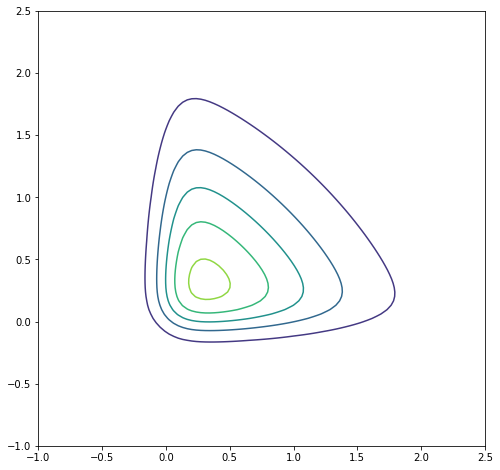

In [13]:
x1 = np.linspace(-1,2.5,100)
x2 = np.linspace(-1,2.5,100)
X1,X2 = np.meshgrid(x1,x2)
Z = f2d(X1,X2)
plt.figure(figsize=(8,8))
contourplot = plt.contour(X1,X2,Z)

In [14]:
contourplot.levels

array([0.  , 0.15, 0.3 , 0.45, 0.6 , 0.75, 0.9 ])

In [10]:
# normalize
h1 = x1[1]-x1[0]
h2 = x2[1]-x2[0]
norm_const = trapezoid(trapezoid(Z, dx=h2, axis=0), dx=h1)
Z_norm = Z/norm_const

# compute marginals
x1marginal = trapezoid(Z_norm, dx=h2, axis=0)
x2marginal = trapezoid(Z_norm, dx=h1, axis=1)

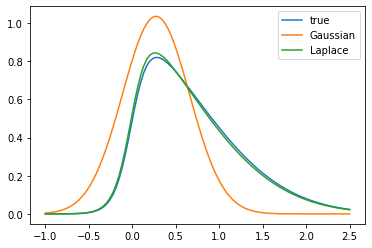

In [11]:
def Gauss_approx(f,negloghess,x):
    h = x[1]-x[0]
    map_pt = minimize_scalar(lambda x: -f(x), bounds=(-5, 10), method="bounded").x
    hess = negloghess(map_pt)
    return lambda x: norm.pdf(x, map_pt, hess**-0.5), map_pt

def Laplace_approx(x,dim):
    px = np.zeros(np.size(x))
    h = x[1]-x[0]
    for i in range(np.size(x)):
        if dim == 1:
            ycond = lambda x: f2d(x1[i],x)/norm_const
        elif dim == 2:
            ycond = lambda x: f2d(x,x2[i])/norm_const
        Gauss,map_pt = Gauss_approx(ycond,negloghess,x)
        #if i%10 == 0:
            #plt.plot(x,ycond(x))
        px[i] = ycond(map_pt)/Gauss(map_pt)
    return px

Lapprox = Laplace_approx(x2,2)
# Laplace approx does not integrate to 1, because the Gaussian approximation at the mode is off by a big constant
Lapprox_int = trapezoid(Lapprox,dx=h2)
Lapprox = Lapprox/Lapprox_int

# Gauss approx to marginal
map_i = np.argmax(x2marginal)
marg_hess = (-np.log(x2marginal[map_i-1]) + 2*np.log(x2marginal[map_i]) - np.log(x2marginal[map_i+1]))/h2**2
Gauss_marg = norm.pdf(x2,x2[map_i],marg_hess**-0.5)

plt.plot(x2,x2marginal,label='true')
plt.plot(x2,Gauss_marg,label='Gaussian')
plt.plot(x2,Lapprox,label='Laplace')
plt.legend()

In [12]:
# Sample data

# Create a header string
header = "x \t\t true \t\t Gauss \t\t Laplace"

# Save the data with the header
np.savetxt("images/Laplace_demo.txt", np.column_stack((x2, x2marginal, Gauss_marg, Lapprox)), delimiter="\t", header=header, fmt='%10.8f', comments="")